# WikiProject Medicine — Overview

In this project, you are acting as **data scientists for the Wikimedia Foundation**.

You have **three datasets** about medical articles on Wikipedia:

1. **Edits**: who changed what, where and when.
2. **Article ratings**: how good and how important each article is.
3. **Talk page comments**: who discussed what on article talk pages.

This notebook we will:

- Load each dataset.
- Look at its main variables.
- Understand how to link them using `page_id`

In [1]:
import pandas as pd
import os

# PHASE 0. DATA LOADING and EXPLORATION
## ADJUST THE PATHS 

In [2]:
EDITS_PATH = "data/revision_sample_800_articles.csv"
RATINGS_PATH = "data/wp_medicine_ratings_800_sample.csv"
COMMENTS_PATH = "data/all_comments_800_sample.csv"

## 1. Loading the data 

The data comes from the public Wikipedia dumps, which are archives that Wikipedia makes available online for free. These dumps contain the raw content of Wikipedia pages and metadata.

You can learn more about them here: https://meta.wikimedia.org/wiki/Data_dumps#:~:text=About%20Wikimedia%20Dumps&text=The%20dumps%20are%20used%20by,are%20produced%20once%20per%20month.

However, this is not the most important part of the project, the key focus is how to use this data

In [3]:
edits_df = pd.read_csv(EDITS_PATH)
ratings_df = pd.read_csv(RATINGS_PATH)
comments_df = pd.read_csv(COMMENTS_PATH)
edits_df.shape, ratings_df.shape, comments_df.shape

/tmp/ipykernel_3626/3749685129.py:1: DtypeWarning: Columns (0: event_user_is_anonymous) have mixed types. Specify dtype option on import or set low_memory=False.
  edits_df = pd.read_csv(EDITS_PATH)


((175365, 28), (800, 12), (3626, 9))

don't worry about the warning 

### 1. Edits dataset — `revision_sample_800_articles.csv`

**What is this file?**

Each row in this dataset represents **one edit** (one revision) to a medical article 

You can use it to study:

- Who edits which articles.
- How big their edits are.
- When edits happen 
- Whether edits are reverted (undone by another editor : meaning if a later editor cancels the edit)

**Key idea:** this file is our main source of **collaboration activity**.

In [4]:
edits_df.head()

,event_entity,event_timestamp,event_comment,event_user_text_historical,event_user_is_bot_by,event_user_is_anonymous,event_user_is_permanent,event_user_registration_timestamp,event_user_creation_timestamp,event_user_first_edit_timestamp,...,page_revision_count,page_seconds_since_previous_revision,revision_id,revision_parent_id,revision_minor_edit,revision_text_bytes,revision_text_bytes_diff,revision_is_identity_reverted,revision_is_identity_revert,revision_tags
0,revision,2003-02-19 21:45:36,"added ""trade-name"" Zyprexa for Olanzapine",Tzuhou,NaN,False,True,2003-02-19 20:11:40,NaN,2003-02-19 20:11:40,...,21.0,3380309.0,682836.0,682695.0,True,6117.0,10.0,False,False,NaN
1,revision,2003-02-19 22:19:45,NaN,Susan Mason,NaN,False,True,2003-02-18 12:44:29,NaN,2003-02-18 12:44:29,...,22.0,2049.0,682888.0,682836.0,False,6108.0,-9.0,False,False,NaN
2,revision,2003-02-19 22:35:36,NaN,Susan Mason,NaN,False,True,2003-02-18 12:44:29,NaN,2003-02-18 12:44:29,...,23.0,951.0,682890.0,682888.0,True,6110.0,2.0,False,False,NaN
3,revision,2003-02-19 22:36:03,NaN,Susan Mason,NaN,False,True,2003-02-18 12:44:29,NaN,2003-02-18 12:44:29,...,24.0,27.0,682892.0,682890.0,True,6124.0,14.0,False,False,NaN
4,revision,2003-02-19 22:36:22,NaN,Susan Mason,NaN,False,True,2003-02-18 12:44:29,NaN,2003-02-18 12:44:29,...,25.0,19.0,686312.0,682892.0,True,6043.0,-81.0,False,False,NaN


#### 1.1 Main variables in the edits dataset

You don't have to every column

Here are the most important ones:

**About the edit (event)**

- `event_timestamp` – When the edit happened (date and time).
- `event_comment` – Short message written by the editor to explain the change.

**About the editor**

- `event_user_text_historical` – Username or IP address of the editor.
- `event_user_is_anonymous` – `True` if the editor is an IP (no account).
- `event_user_revision_count` – Total number of edits this editor has made.

**About the article**

- `page_id` – Unique numeric ID of the article.  
  This is the key that links all three datasets.
- `page_title` – Title of the article.
- `page_revision_count` – Total number of edits the article has received.

**About the revision (content change)**

- `revision_text_bytes` – Size of the article after this edit.
- `revision_text_bytes_diff` – Change in size for this edit  
  (positive = added text, negative = removed text).
- `revision_is_identity_revert` – `True` if this edit reverted another edit.
- `revision_is_identity_reverted` – `True` if this edit was later reverted.

You can use these variables to build:

- Editor–article networks.
- Editor–editor co-edit networks.
- Measures of edit size, conflict, and coordination.

In [5]:
print("Number of rows (edits):", len(edits_df))
print("Number of unique articles:", edits_df["page_id"].nunique())
print("Number of unique editors:", edits_df["event_user_text_historical"].nunique())

edits_df[["event_timestamp", "event_user_text_historical", "page_id", "revision_text_bytes_diff"]].head()

Number of rows (edits): 175365
Number of unique articles: 800
Number of unique editors: 53297


,event_timestamp,event_user_text_historical,page_id,revision_text_bytes_diff
0,2003-02-19 21:45:36,Tzuhou,2870,10.0
1,2003-02-19 22:19:45,Susan Mason,2870,-9.0
2,2003-02-19 22:35:36,Susan Mason,2870,2.0
3,2003-02-19 22:36:03,Susan Mason,2870,14.0
4,2003-02-19 22:36:22,Susan Mason,2870,-81.0


In [6]:
edits_df_used = edits_df[[
                            # About the edit (event)
                            "event_timestamp", "event_comment", 
                            # About the editor (user)
                            "event_user_text_historical", "event_user_is_anonymous", "event_user_revision_count",
                            # About the article (page)
                            "page_id", "page_title", "page_revision_count",
                            # About the revision (content change)
                            "revision_text_bytes", "revision_text_bytes_diff", "revision_is_identity_revert", "revision_is_identity_reverted"]]

In [7]:
edits_df_used.info()

<class 'pandas.DataFrame'>
RangeIndex: 175365 entries, 0 to 175364
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   event_timestamp                175365 non-null  str    
 1   event_comment                  143136 non-null  str    
 2   event_user_text_historical     175353 non-null  str    
 3   event_user_is_anonymous        175353 non-null  object 
 4   event_user_revision_count      126125 non-null  float64
 5   page_id                        175365 non-null  int64  
 6   page_title                     175365 non-null  str    
 7   page_revision_count            173939 non-null  float64
 8   revision_text_bytes            173053 non-null  float64
 9   revision_text_bytes_diff       172921 non-null  float64
 10  revision_is_identity_revert    173939 non-null  object 
 11  revision_is_identity_reverted  173939 non-null  object 
dtypes: float64(4), int64(1), object(3), str(4

In [8]:
edits_df_used.describe()

,event_user_revision_count,page_id,page_revision_count,revision_text_bytes,revision_text_bytes_diff
count,1.261250e+05,1.753650e+05,173939.000000,173053.000000,172921.000000
mean,5.966948e+04,1.692635e+07,779.298357,38610.182904,40.601755
std,2.297411e+05,2.261693e+07,1061.659470,54667.865610,4481.859637
min,1.000000e+00,2.870000e+03,1.000000,0.000000,-521664.000000
25%,3.830000e+02,3.345910e+05,87.000000,7763.000000,-5.000000
50%,6.251000e+03,4.040810e+06,325.000000,18591.000000,5.000000
75%,3.746800e+04,2.516467e+07,1033.500000,45894.000000,59.000000
max,6.264446e+06,7.830278e+07,6548.000000,549812.000000,521664.000000


### 2. Article ratings dataset — `wp_medicine_ratings_800_sample.csv`

**What is this file?**

Each row in this dataset represents **one article**.  

It tells you how articles has assessed:

- The **quality** of the article (e.g., Stub, Start, C, B, GA, FA). Here is a link to help you understand what each rating means : https://en.wikipedia.org/wiki/Wikipedia:Content_assessment. For example,  FA means : featured article and it's the best possible rating. 

- The **importance** of the article (e.g., Low, Mid, High, Top). Importance is how much of a priority an article is for a given project. For example :  Low-importance → The article is not a priority for that WikiProject. It covers a topic that is relevant but not central.

Mid-importance → Moderately important; useful or notable within the project.

High-importance → Very important; core topic

This helps you link collaboration patterns to how good/important the article is.

In [9]:
ratings_df.head()

,article,importance,importance_updated,quality,quality_updated,article_history_link,article_link,article_talk,article_talk_link,title,page_id,ns
0,William S. Sadler,Low-Class,2012-03-14T18:16:30Z,FA-Class,2012-06-24T00:33:08Z,https://en.wikipedia.org/w/index.php?title=Wil...,https://en.wikipedia.org/w/index.php?title=Wil...,Talk:William S. Sadler,https://en.wikipedia.org/w/index.php?title=Tal...,William S. Sadler,2113994,0.0
1,List of books bound in human skin,Low-Class,2023-09-03T04:02:48Z,FL-Class,2023-10-09T00:25:40Z,https://en.wikipedia.org/w/index.php?title=Lis...,https://en.wikipedia.org/w/index.php?title=Lis...,Talk:List of books bound in human skin,https://en.wikipedia.org/w/index.php?title=Tal...,List of books bound in human skin,74680914,0.0
2,Hemothorax,Mid-Class,2007-10-11T21:33:48Z,GA-Class,2019-04-25T16:47:04Z,https://en.wikipedia.org/w/index.php?title=Hem...,https://en.wikipedia.org/w/index.php?title=Hem...,Talk:Hemothorax,https://en.wikipedia.org/w/index.php?title=Tal...,Hemothorax,2166658,0.0
3,Histamine N-methyltransferase,Mid-Class,2023-12-01T11:35:19Z,GA-Class,2024-03-26T19:05:02Z,https://en.wikipedia.org/w/index.php?title=His...,https://en.wikipedia.org/w/index.php?title=His...,Talk:Histamine N-methyltransferase,https://en.wikipedia.org/w/index.php?title=Tal...,Histamine N-methyltransferase,11472211,0.0
4,"2,3,7,8-Tetrachlorodibenzodioxin",Low-Class,2010-02-09T21:59:21Z,GA-Class,2012-10-14T02:09:51Z,https://en.wikipedia.org/w/index.php?title=2%2...,https://en.wikipedia.org/w/index.php?title=2%2...,"Talk:2,3,7,8-Tetrachlorodibenzodioxin",https://en.wikipedia.org/w/index.php?title=Tal...,"2,3,7,8-Tetrachlorodibenzodioxin",23789332,0.0


#### 2.1 Main variables in the ratings dataset

- `page_id` – Article ID (same as in the edits dataset).  
- `article` / `title` – Title of the article.
- `quality` – Quality rating (e.g., `FA-Class`, `GA-Class`, `B-Class`, `Start-Class`, `Stub-Class`).
- `quality_updated` – When the quality rating was last updated.
- `importance` – Importance rating inside WikiProject Medicine (`Top-Class`, `High-Class`, `Mid-Class`, etc.).
- `importance_updated` – When the importance rating was last updated.

Other columns (`article_link`, `article_history_link`, `article_talk_link`) are URLs and not essential for the analysis.

In [10]:
print("Rows in ratings_df:", len(ratings_df))
print("Unique articles in ratings_df:", ratings_df["page_id"].nunique())

# How many of our 800 sampled articles have ratings?
common_ids = set(edits_df["page_id"].unique()) & set(ratings_df["page_id"].unique())
print("Articles present in both edits and ratings:", len(common_ids))

Rows in ratings_df: 800
Unique articles in ratings_df: 800
Articles present in both edits and ratings: 800


In [11]:
ratings_df_used = ratings_df[[
                                "page_id", "article", "title",
                                "quality", "quality_updated",
                                "importance", "importance_updated"]]

In [12]:
ratings_df_used.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   page_id             800 non-null    int64
 1   article             800 non-null    str  
 2   title               800 non-null    str  
 3   quality             800 non-null    str  
 4   quality_updated     800 non-null    str  
 5   importance          800 non-null    str  
 6   importance_updated  800 non-null    str  
dtypes: int64(1), str(6)
memory usage: 43.9 KB


In [13]:
ratings_df_used.describe()

,page_id
count,8.000000e+02
mean,2.997308e+07
std,2.446841e+07
min,2.870000e+03
25%,5.104824e+06
50%,2.539226e+07
75%,5.265810e+07
max,7.830278e+07


### 3. Talk comments dataset — `all_comments_800_sample.csv`

**What is this file?**

Each row in this dataset represents **one comment** on an article's talk page.

On Wikipedia, each article has a **talk page** where editors discuss:

- Proposed changes
- Disagreements
- Sources
- Structure of the article

This file lets you study **who talks to whom, and when**, about which article.

In [14]:
comments_df.head()

,id,section,user,timestamp,comment,parent_id,indent_level,article,page_id
0,2113994_53cde6_1,(untitled),T. Anthony,"08:51, 6 October 2005",Something about this strikes me as vaguely POV...,NaN,0,William S. Sadler,2113994
1,2113994_6fbd41_1,Improvements,Edivorce,"16:37, 16 December 2005",A few months ago I made some minor edits to th...,NaN,0,William S. Sadler,2113994
2,2113994_6fbd41_2,Improvements,96.239.135.225,"22:41, 21 August 2008",Sadler published a book titled Long Heads and ...,NaN,0,William S. Sadler,2113994
3,2113994_cf045e_1,More improvements needed,ScienceStorm,"04:36, 10 July 2009",In the text:\n“Sadler did not adhere to purely...,NaN,0,William S. Sadler,2113994
4,2113994_b7525f_1,Inadequate Article,Ldmjr,"08:15, 16 August 2009",This article serious misrepresents the man and...,NaN,0,William S. Sadler,2113994


#### 3.1 Main variables in the talk comments dataset

- `page_id` – Article ID (same as in the edits and ratings datasets).
- `article` – Article title.

- `id` – Unique ID of the comment.
- `section` – Title of the discussion section on the talk page.
- `user` – Username of the person who wrote the comment.
- `timestamp` – When the comment was posted (wiki time format).
- `comment` – Text of the comment.

- `parent_id` – If this is a reply, the `id` of the comment it replies to.  
  If empty, it starts a new thread.
- `indent_level` – Depth of the reply (0 = main comment, 1 = reply, 2 = reply to reply, etc.).

This dataset is useful if you want to look at:

- Discussion intensity per article.
- Who interacts with whom on talk pages.
- Relation between talk activity, edit patterns, and article quality.

In [15]:
print("Rows in comments_df:", len(comments_df))
print("Unique articles with comments:", comments_df["page_id"].nunique())

common_ids_comments = set(edits_df["page_id"].unique()) & set(comments_df["page_id"].unique())
print("Articles present in both edits and comments:", len(common_ids_comments))

print("Unique users in comments_df:", comments_df["user"].nunique())
common_ids_users = set(edits_df["event_user_text_historical"].unique()) & set(comments_df["user"].unique())
print("Users present in both edits and comments:", len(common_ids_users))

Rows in comments_df: 3626
Unique articles with comments: 417
Articles present in both edits and comments: 417
Unique users in comments_df: 1800
Users present in both edits and comments: 914


In [16]:
comments_df_used = comments_df[[
                                "page_id", "article", "id", "section",
                                "user", "timestamp", "comment",
                                "parent_id", "indent_level"]]

In [17]:
comments_df_used.info()

<class 'pandas.DataFrame'>
RangeIndex: 3626 entries, 0 to 3625
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   page_id       3626 non-null   int64
 1   article       3626 non-null   str  
 2   id            3626 non-null   str  
 3   section       3621 non-null   str  
 4   user          3626 non-null   str  
 5   timestamp     3626 non-null   str  
 6   comment       3626 non-null   str  
 7   parent_id     1114 non-null   str  
 8   indent_level  3626 non-null   int64
dtypes: int64(2), str(7)
memory usage: 255.1 KB


In [18]:
comments_df_used.describe()

,page_id,indent_level
count,3.626000e+03,3626.000000
mean,1.471866e+07,0.760618
std,2.101535e+07,1.619895
min,2.870000e+03,0.000000
25%,4.110210e+05,0.000000
50%,2.859941e+06,0.000000
75%,2.108828e+07,1.000000
max,7.727468e+07,17.000000


### Hint for next step: 4. How the datasets fit together

All three datasets share the same key: **`page_id`**.

- The **edits dataset** (`revision_sample_800_articles.csv`) tells you:
  - Who edited which article, when, and how much they changed.

- The **ratings dataset** (`wp_medicine_ratings_800_sample.csv`) tells you:
  - How good and important each article is (quality and importance).

- The **talk comments dataset** (`all_comments_800_sample.csv`) tells you:
  - Who discussed which article on the talk page, and what they said.

You will use `page_id` to join these datasets when/ if needed.

## 3. Data Description

In [30]:
# =========================
# Data Description
# =========================

# Basic counts
num_editors = edits_df_used["event_user_text_historical"].nunique()
num_articles = edits_df_used["page_id"].nunique()
num_commenters = comments_df_used["user"].nunique()

# Editors and commenters per article
editors_per_article = edits_df_used.groupby("page_id")["event_user_text_historical"].nunique().reset_index(name="num_editors")
commenters_per_article = comments_df_used.groupby("page_id")["user"].nunique().reset_index(name="num_commenters")

# Articles per editor/commenter
articles_per_editor = edits_df_used.groupby("event_user_text_historical")["page_id"].nunique().reset_index(name="num_articles_edited")
articles_per_commenter = comments_df_used.groupby("user")["page_id"].nunique().reset_index(name="num_articles_commented")

# Distribution of articles edited/commented per user
articles_edited_distribution = articles_per_editor["num_articles_edited"].value_counts().to_dict()
articles_commented_distribution = articles_per_commenter["num_articles_commented"].value_counts().to_dict()

# Quality and importance distributions
importance_distribution = ratings_df_used["importance"].value_counts().to_dict()
quality_distribution = ratings_df_used["quality"].value_counts().to_dict()

# =========================
# User overlap analysis
# =========================

users_in_edits = set(edits_df_used["event_user_text_historical"].dropna().unique())
users_in_comments = set(comments_df_used["user"].dropna().unique())

both_users = users_in_edits & users_in_comments
only_editors = users_in_edits - users_in_comments
only_commenters = users_in_comments - users_in_edits

# =========================
# Print summary statistics
# =========================

print(f"Total unique editors: {num_editors}")
print(f"Total unique commenters: {num_commenters}")
print(f"Total unique articles: {num_articles}")

print(f"\nAverage number of unique editors per article: {editors_per_article['num_editors'].mean():.2f}")
print(f"Average number of unique commenters per article: {commenters_per_article['num_commenters'].mean():.2f}")

print(f"\nAverage number of articles edited per editor: {articles_per_editor['num_articles_edited'].mean():.2f}")
print(f"Average number of articles commented on per commenter: {articles_per_commenter['num_articles_commented'].mean():.2f}")

print("\nImportance rating distribution:", importance_distribution)
print("Quality rating distribution:", quality_distribution)

print("\nTop 5 most common article counts per editor:",
      dict(sorted(articles_edited_distribution.items(), key=lambda x: x[1], reverse=True)[:5]))

print("Top 5 most common article counts per commenter:",
      dict(sorted(articles_commented_distribution.items(), key=lambda x: x[1], reverse=True)[:5]))

print("\nTop 5 least common article counts per editor:",
      dict(sorted(articles_edited_distribution.items(), key=lambda x: x[1])[:5]))

print("Top 5 least common article counts per commenter:",
      dict(sorted(articles_commented_distribution.items(), key=lambda x: x[1])[:5]))

print(f"\nUsers who both edited and commented: {len(both_users)}")
print(f"Users who only edited: {len(only_editors)}")
print(f"Users who only commented: {len(only_commenters)}")
print(f"Users who did nothing: {len(set.union(users_in_edits, users_in_comments)) - len(both_users) - len(only_editors) - len(only_commenters)}")

Total unique editors: 53297
Total unique commenters: 1800
Total unique articles: 800

Average number of unique editors per article: 95.56
Average number of unique commenters per article: 5.32

Average number of articles edited per editor: 1.43
Average number of articles commented on per commenter: 1.23

Importance rating distribution: {'Low-Class': 573, 'Mid-Class': 188, 'Unknown-Class': 20, 'High-Class': 16, 'NA-Class': 2, 'Top-Class': 1}
Quality rating distribution: {'Start-Class': 360, 'C-Class': 188, 'Stub-Class': 167, 'B-Class': 61, 'List-Class': 13, 'GA-Class': 7, 'Disambig-Class': 2, 'FA-Class': 1, 'FL-Class': 1}

Top 5 most common article counts per editor: {1: 47971, 2: 2673, 3: 868, 4: 463, 5: 307}
Top 5 most common article counts per commenter: {1: 1691, 2: 70, 3: 15, 4: 5, 5: 5}

Top 5 least common article counts per editor: {53: 1, 75: 1, 133: 1, 121: 1, 107: 1}
Top 5 least common article counts per commenter: {10: 1, 29: 1, 16: 1, 82: 1, 24: 1}

Users who both edited and 

/tmp/ipykernel_3626/3177931849.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


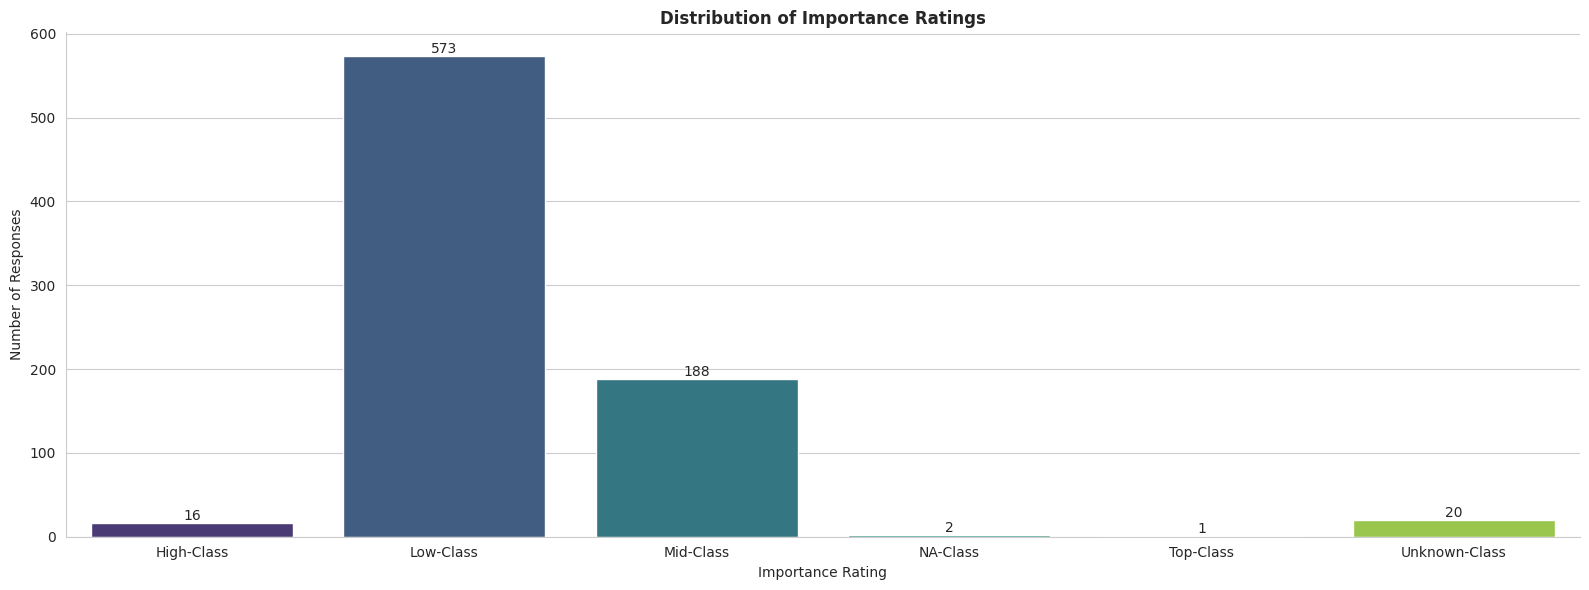

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
# sns.set_context("talk")

# Create figure
plt.figure(figsize=(16, 6))

# Define rating order (change if your scale is different)
order = sorted(ratings_df_used["importance"].unique())

# Plot
ax = sns.countplot(
    x="importance",
    data=ratings_df_used,
    order=order,
    palette="viridis"
)

# Add labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title("Distribution of Importance Ratings", weight="bold")
plt.xlabel("Importance Rating")
plt.ylabel("Number of Responses")

# Improve layout
sns.despine()
plt.tight_layout()

plt.show()

/tmp/ipykernel_3626/349256120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


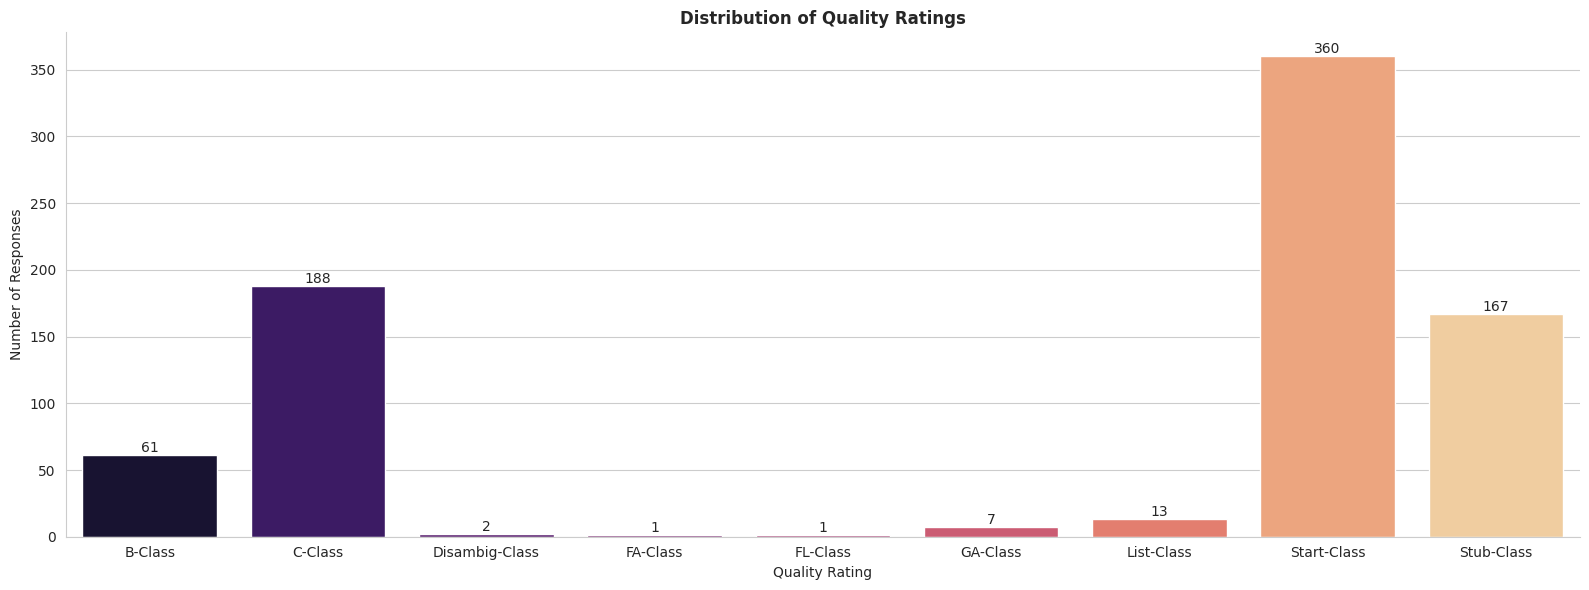

In [21]:
# Distribution of quality ratings
plt.figure(figsize=(16, 6))
order_quality = sorted(ratings_df_used["quality"].unique())
ax = sns.countplot(
    x="quality",
    data=ratings_df_used,
    order=order_quality,
    palette="magma"
)
# Add labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )
# Titles and labels
plt.title("Distribution of Quality Ratings", weight="bold")
plt.xlabel("Quality Rating")
plt.ylabel("Number of Responses")
# Improve layout
sns.despine()
plt.tight_layout()
plt.show()

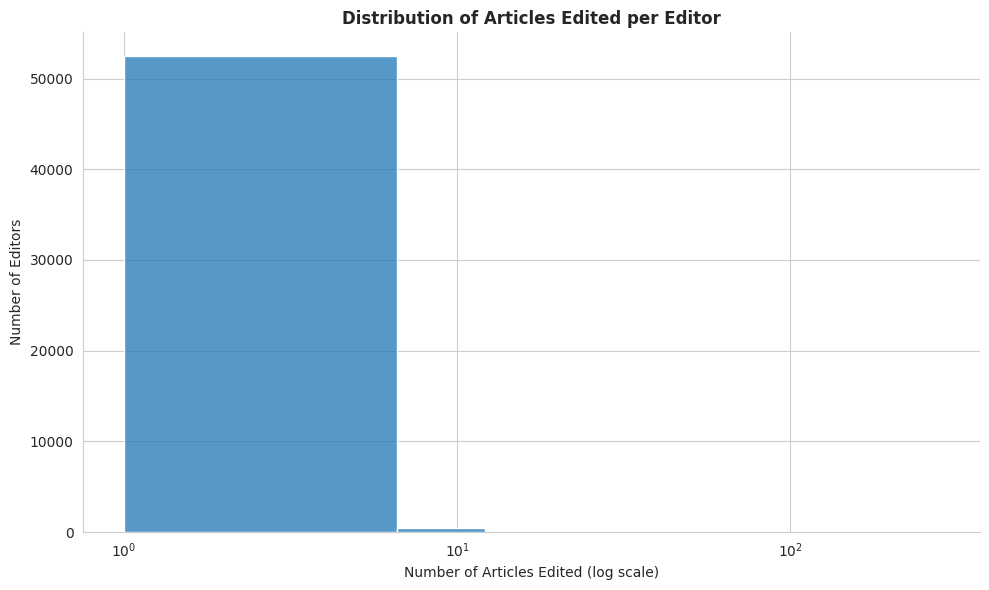

In [40]:
# Distribution of Articles Edited per Editor (Log Scale)
plt.figure(figsize=(10,6))

sns.histplot(
    articles_per_editor["num_articles_edited"],
    bins=50
)

plt.xscale("log")

plt.title("Distribution of Articles Edited per Editor", weight="bold")
plt.xlabel("Number of Articles Edited (log scale)")
plt.ylabel("Number of Editors")

sns.despine()
plt.tight_layout()
plt.show()

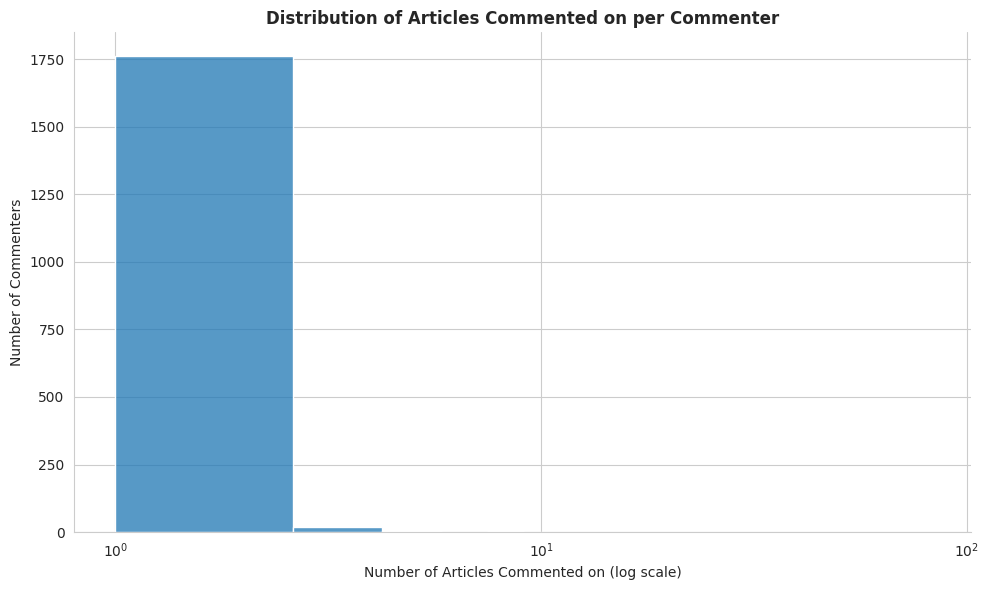

In [41]:
# Distribution of articles commented on per commenter (Log scale)
plt.figure(figsize=(10,6))

sns.histplot(
    articles_per_commenter["num_articles_commented"],
    bins=50
)

plt.xscale("log")

plt.title("Distribution of Articles Commented on per Commenter", weight="bold")
plt.xlabel("Number of Articles Commented on (log scale)")
plt.ylabel("Number of Commenters")

sns.despine()
plt.tight_layout()
plt.show()

In [28]:
# Dataset Size and Coverage
total_edits = len(edits_df_used)
total_comments = len(comments_df_used)
total_ratings = len(ratings_df_used)

print(f"Total edit events: {total_edits}")
print(f"Total comment events: {total_comments}")
print(f"Total article ratings: {total_ratings}")

Total edit events: 175365
Total comment events: 3626
Total article ratings: 800


**Comment:** The dataset contains:
* 175,365 edit events performed by 53,297 editors across 800 articles.
* 3,626 comment events performed by 1,800 commenters across 800 articles.
* All articles have ratings

In [29]:
# Distribution Statistics
print("\nArticles edited per editor statistics:")
print(articles_per_editor["num_articles_edited"].describe())

print("\nArticles commented per commenter statistics:")
print(articles_per_commenter["num_articles_commented"].describe())


Articles edited per editor statistics:
count    53297.000000
mean         1.434302
std          4.017679
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        280.000000
Name: num_articles_edited, dtype: float64

Articles commented per commenter statistics:
count    1800.000000
mean        1.231667
std         2.522428
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        82.000000
Name: num_articles_commented, dtype: float64


**Comment:**
* Although the mean number of edited articles per editor is 1.4, the median is 1, indicating that most editors contribute to only a single article.
* Although the mean number of commented articles per editor is 1.2, the median is 1, indicating that most commenters contribute to only a single article.

In [31]:
# Activity Inequality
print("\nEditor activity percentiles:")
print(articles_per_editor["num_articles_edited"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))


Editor activity percentiles:
0.50    1.0
0.75    1.0
0.90    1.0
0.95    2.0
0.99    9.0
Name: num_articles_edited, dtype: float64


In [33]:
# Activity Inequality
print("\nCommenter activity percentiles:")
print(articles_per_commenter["num_articles_commented"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))


Commenter activity percentiles:
0.50    1.0
0.75    1.0
0.90    1.0
0.95    2.0
0.99    5.0
Name: num_articles_commented, dtype: float64


In [34]:
# Article Collaboration Statistics
print("\nEditors per article statistics:")
print(editors_per_article["num_editors"].describe())

print("\nCommenters per article statistics:")
print(commenters_per_article["num_commenters"].describe())


Editors per article statistics:
count     800.000000
mean       95.555000
std       229.025698
min         2.000000
25%        13.000000
50%        30.000000
75%        76.000000
max      2597.000000
Name: num_editors, dtype: float64

Commenters per article statistics:
count    417.000000
mean       5.316547
std        6.606417
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       42.000000
Name: num_commenters, dtype: float64


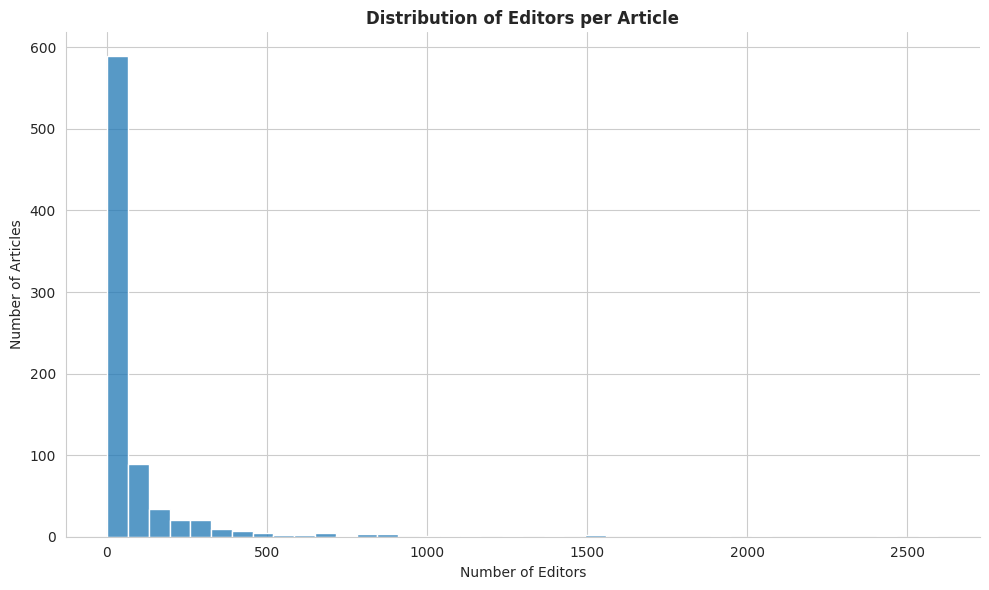

In [58]:
# Article Collaboration (Editors per Article)
plt.figure(figsize=(10,6))

sns.histplot(
    editors_per_article["num_editors"],
    bins=40
)

plt.title("Distribution of Editors per Article", weight="bold")
plt.xlabel("Number of Editors")
plt.ylabel("Number of Articles")

sns.despine()
plt.tight_layout()
plt.show()

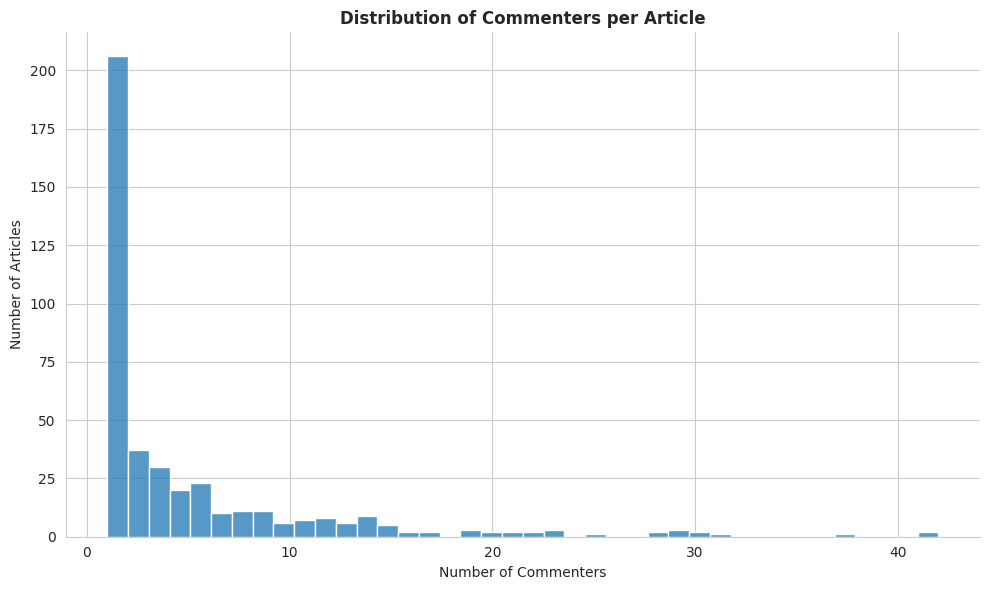

In [61]:
# Distribution of Commenters per Article
plt.figure(figsize=(10,6))
sns.histplot(
    commenters_per_article["num_commenters"],
    bins=40
)
plt.title("Distribution of Commenters per Article", weight="bold")
plt.xlabel("Number of Commenters")
plt.ylabel("Number of Articles")
sns.despine()
plt.tight_layout()
plt.show()

**Comments:**
* Most articles are edited by less than 100 (small number comparing to the total) contributors, with a median of 13.0 editors per article.
* Most articles are commented by less than 10 (small number comparing to the total) contributors, with a median of 3.0 commenters per article.

In [35]:
# User Role Proportions
total_users = len(users_in_edits | users_in_comments)

print(f"\nTotal unique users: {total_users}")

print(f"Users who both edited and commented: {len(both_users)} ({len(both_users)/total_users:.2%})")
print(f"Users who only edited: {len(only_editors)} ({len(only_editors)/total_users:.2%})")
print(f"Users who only commented: {len(only_commenters)} ({len(only_commenters)/total_users:.2%})")


Total unique users: 54183
Users who both edited and commented: 914 (1.69%)
Users who only edited: 52383 (96.68%)
Users who only commented: 886 (1.64%)


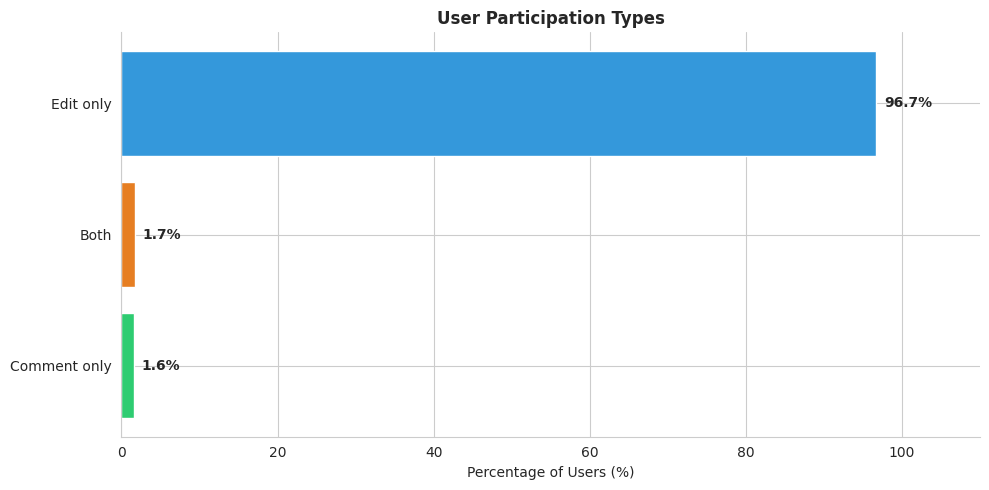

In [56]:
# User Participation Types (Pie Chart)

# Data
labels = ["Edit only", "Comment only", "Both"]
sizes = [len(only_editors), len(only_commenters), len(both_users)]

# Sort data for better presentation
data = sorted(zip(labels, percentages), key=lambda x: x[1])
s_labels, s_pcts = zip(*data)

plt.figure(figsize=(10, 5))
bars = plt.barh(s_labels, s_pcts, color=colors[::-1])

# Add labels to the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width}%', 
             va='center', fontweight='bold')

plt.title("User Participation Types", weight="bold")
plt.xlabel("Percentage of Users (%)")
plt.xlim(0, 110) # Room for text
plt.gca().spines[['top', 'right']].set_visible(False) # Clean look

plt.tight_layout()
plt.show()

**Comment:** The majority of users participate exclusively through editing, while only a small fraction engage in both editing and discussion activities.

In [36]:
# Article Rating Coverage
rated_articles = ratings_df_used["page_id"].nunique()

print(f"\nArticles with ratings: {rated_articles}")
print(f"Percentage of articles rated: {rated_articles / num_articles:.2%}")


Articles with ratings: 800
Percentage of articles rated: 100.00%


In [37]:
# Missing Data
print("\nMissing values:")
print("Missing edit users:", edits_df_used["event_user_text_historical"].isna().sum())
print("Missing comment users:", comments_df_used["user"].isna().sum())


Missing values:
Missing edit users: 12
Missing comment users: 0


## **General Comments:**
### **1. Dataset Overview**
Our dataset represents activity on 800 articles with:
* 175,365 edit events
* 3,626 comment events
* 800 article ratings

These interactions are generated by:
* 53,297 editors
* 1,800 commenters
* 54,183 unique users in total

A very important observation is the **large difference between editors and commenters**, indicating that editing activity is far more common than discussion activity.

### **2. User Participation Patterns**
User participation is highly asymmetric.
* 96.68% of users only edit articles
* 1.64% only comment
* 1.69% both edit and comment

This shows that **discussion participation is extremely limited compared to editing**.

Only **914 users engage in both editing and commenting**, suggesting that the **editing and discussion communities largely consist of different users**.

### **3.Editor Activity Distribution**
Editor activity is extremely skewed.
* Average articles edited per editor: 1.43
* Median: 1
* Maximum: 280

Percentile analysis shows:
* 90% of editors edit only one article
* 95% edit at most two articles
* 99% edit fewer than nine articles

This indicates a **long-tail distribution**, where the majority of editors contribute to only a single article, while a very small number of highly active editors contribute to many articles.

This pattern is typical in collaborative platforms such as Wikipedia, where a small core of contributors produces a large share of edits. 

### **Commenter Activity Distribution**
Commenting activity shows a similar but smaller pattern.
* Average articles commented per commenter: 1.23
* Median: 1
* Maximum: 82

Percentile results show:
* 90% comment on only one article
* 95% comment on at most two articles

Thus, discussion participation is **both less frequent and less distributed** than editing activity.

### **5. Collaboration per Article**
Articles receive contributions from many editors.
* Average editors per article: 95.56
* Median editors per article: 30
* Maximum editors: 2,597

The large difference between the **mean and median** indicates that some articles attract **very large collaborative communities**, while most articles have moderate participation.

For discussions:

* Average commenters per article: 5.32
* Median: 3
* Maximum: 42

Thus, **editing collaboration is much larger than discussion collaboration**.

### **6. Article Quality and Importance**
All **800 articles have both quality and importance ratings**, ensuring complete coverage.

#### **Importance distribution**
Most articles are classified as:
* Low importance: 573 articles
* Mid importance: 188 articles

Very few articles are rated as:
* High importance: 16
* Top importance: 1

This indicates the dataset is dominated by **lower-importance articles**, with only a small number considered highly important.

#### **Quality distribution**
Most articles fall in **early development stages**:
* Start-Class: 360
* Stub-Class: 167
* C-Class: 188

Only a small number reach **high-quality levels**:
* GA (Good Article): 7
* FA (Featured Article): 1
* FL (Featured List): 1

This suggests that the dataset largely contains **developing or incomplete articles**, rather than highly polished content.

### **7. Data Quality**
The dataset contains very few missing values:
* 12 missing edit user entries
* 0 missing comment users

This indicates the dataset is **highly complete**, with minimal missing information.

## Key Structural Characteristics of the Dataset
Overall, the dataset exhibits three main structural properties:
1. Highly skewed participation
    * Most users contribute very little
    * A small minority contributes heavily

2. Editing dominates discussion
    * Editing activity is far more common than commenting
    * Strong collaboration on articles

3. Articles often involve dozens or hundreds of editors
    * These characteristics are typical of large-scale collaborative knowledge platforms.

# Draft:
The Gini coefficient would be an excellent idea for your dataset. In fact, studies analyzing collaborative platforms (especially Wikipedia) often use both the Lorenz curve and the Gini coefficient to quantify inequality in contributions.

## Gini coefficient
Our statistics already strongly suggest very unequal participation, so computing Gini will give you a clear quantitative measure of that inequality.

Why Gini is Useful for Your Dataset
* Our results already show:
    * 90% of editors edit only 1 article
    * Mean = 1.43 but median = 1
    * Max = 280 articles
* This indicates a **small number of highly active contributors dominate activity**.
* The Gini coefficient summarizes this inequality in a single number:
    * 0 → perfect equality (everyone contributes equally)
    * 1 → maximum inequality (one user does everything)

| Gini Range | Meaning |
| :--- | :--- |
| **0 – 0.2** | Very equal |
| **0.2 – 0.4** | Moderate inequality |
| **0.4 – 0.6** | High inequality |
| **0.6+** | Extreme inequality |

In [62]:
# Compute the Gini Coefficient

import numpy as np

def gini(array):
    array = np.array(array)
    array = array.flatten()

    if np.amin(array) < 0:
        array -= np.amin(array)

    array = array + 1e-9
    array = np.sort(array)

    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]

    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


editor_gini = gini(articles_per_editor["num_articles_edited"])
commenter_gini = gini(articles_per_commenter["num_articles_commented"])

print(f"Gini coefficient (editor activity): {editor_gini:.3f}")
print(f"Gini coefficient (commenter activity): {commenter_gini:.3f}")

Gini coefficient (editor activity): 0.292
Gini coefficient (commenter activity): 0.184


In [64]:
# Gini of total edits per editor:
edits_per_editor = edits_df_used.groupby("event_user_text_historical").size()
editor_edit_gini = gini(edits_per_editor)
print(f"Gini coefficient (edit events per editor): {editor_edit_gini:.3f}")

# Gini of total comments per commenter:
comments_per_commenter = comments_df_used.groupby("user").size()
commenter_comment_gini = gini(comments_per_commenter)
print(f"Gini coefficient (comment events per commenter): {commenter_comment_gini:.3f}")

Gini coefficient (edit events per editor): 0.635
Gini coefficient (comment events per commenter): 0.454


Contribution inequality was measured using the Gini coefficient. When considering **the number of articles edited per editor**, inequality is moderate (Gini = 0.29), indicating that **most editors contribute to a similar number of articles**. However, when measuring **the number of edit events per editor**, inequality increases substantially (Gini = 0.64). This suggests that **while editors typically engage with only a small number of articles, editing intensity is highly concentrated among a small group of highly active contributors**.

Commenting activity exhibits a similar but less pronounced pattern. The Gini coefficient for comment events per commenter is 0.45, indicating **moderate inequality in discussion participation**.

# Phase 1. DATA INTEGRATION and PREPROCESSING

## 1. Standardizing Identifiers: 
We must align the user column in the `comments` dataset with the `event_user_text_historical` column in the `edits` dataset. They will form our `Node IDs`.

In [74]:
# Standardizing identifiers
# 1. Rename columns in edits_df_used to a standard 'user_id'
edits_df_used.rename(columns={"event_user_text_historical": "user_id"}, inplace=True)
# 2. Rename columns in comments_df_used to a standard 'user_id'
comments_df_used.rename(columns={"user": "user_id"}, inplace=True)
# 3. Clean up empty user_id values (if any)
edits_df_used["user_id"] = edits_df_used["user_id"].replace("", pd.NA)
comments_df_used["user_id"] = comments_df_used["user_id"].replace("", pd.NA)
# Drop rows with missing user_id if necessary
edits_df_used.dropna(subset=["user_id"], inplace=True)
comments_df_used.dropna(subset=["user_id"], inplace=True)

# Print out the first few rows to verify changes
print("Edits DataFrame after standardizing user_id:")
print(edits_df_used[["user_id", "page_id", "event_timestamp"]].head())
print("\nComments DataFrame after standardizing user_id:")
print(comments_df_used[["user_id", "page_id", "timestamp"]].head())

Edits DataFrame after standardizing user_id:
       user_id  page_id      event_timestamp
0       Tzuhou     2870  2003-02-19 21:45:36
1  Susan Mason     2870  2003-02-19 22:19:45
2  Susan Mason     2870  2003-02-19 22:35:36
3  Susan Mason     2870  2003-02-19 22:36:03
4  Susan Mason     2870  2003-02-19 22:36:22

Comments DataFrame after standardizing user_id:
          user_id  page_id                timestamp
0      T. Anthony  2113994    08:51, 6 October 2005
1        Edivorce  2113994  16:37, 16 December 2005
2  96.239.135.225  2113994    22:41, 21 August 2008
3    ScienceStorm  2113994      04:36, 10 July 2009
4           Ldmjr  2113994    08:15, 16 August 2009


## 2. Standardizing Dates: Temporal Conversion
Wikipedia uses specific string formats for dates. To analyze "bursts" of activity later, we must convert these to Python `datetime` objects.

In [75]:
# Ensure timestamps are datetime
edits_df_used['event_timestamp'] = pd.to_datetime(edits_df_used['event_timestamp'], errors='coerce')
comments_df_used['timestamp'] = pd.to_datetime(comments_df_used['timestamp'], errors='coerce')

Note: 

Wikipedia comment timestamps can be messy (e.g., "08:51, 6 October 2005"). 

We use errors='coerce' to turn unparseable dates into NaT (Not a Time) for now.

## 3. Merge Ratings (Importance and Quality) into Editors data as the hint above
This allows us to know the "Importance" of the article being edited during graph construction

In [76]:
# 1. Merge Edits and Eatings on page_id
# This allows us to see the quality of the article every time someone edits it
edits_with_ratings_used = edits_df_used.merge(
    ratings_df_used[["page_id", "quality", "importance"]],
    on="page_id",
    how="left"
)

edits_with_ratings_used[["page_id", "page_title", "user_id", "quality", "importance"]].head()

,page_id,page_title,user_id,quality,importance
0,2870,Antipsychotic,Tzuhou,B-Class,High-Class
1,2870,Antipsychotic,Susan Mason,B-Class,High-Class
2,2870,Antipsychotic,Susan Mason,B-Class,High-Class
3,2870,Antipsychotic,Susan Mason,B-Class,High-Class
4,2870,Antipsychotic,Susan Mason,B-Class,High-Class


In [77]:
# 2. Merge Ratings into Comments
# This allows us to see what kind of articles generate the most discussion
comments_with_ratings_used = comments_df_used.merge(
    ratings_df_used[["page_id", "quality", "importance"]],
    on="page_id",
    how="left"
)

comments_with_ratings_used[["page_id", "article", "user_id", "comment", "quality", "importance"]].head()

,page_id,article,user_id,comment,quality,importance
0,2113994,William S. Sadler,T. Anthony,Something about this strikes me as vaguely POV...,FA-Class,Low-Class
1,2113994,William S. Sadler,Edivorce,A few months ago I made some minor edits to th...,FA-Class,Low-Class
2,2113994,William S. Sadler,96.239.135.225,Sadler published a book titled Long Heads and ...,FA-Class,Low-Class
3,2113994,William S. Sadler,ScienceStorm,In the text:\n“Sadler did not adhere to purely...,FA-Class,Low-Class
4,2113994,William S. Sadler,Ldmjr,This article serious misrepresents the man and...,FA-Class,Low-Class


## 4. Initial Data Check
Just take a quick look at "Anonymous" users.

In [78]:
# Identify Anonymous vs Registered
# Anonymous users usually have an IP address as their name
print(f"Anonymous edits: {edits_with_ratings_used['event_user_is_anonymous'].sum()}")
print(f"Anonymous comments: {comments_with_ratings_used['user_id'].str.contains(r'^\d{1,3}(\.\d{1,3}){3}$').sum()}")    # This regex checks for typical IPv4 format in user_id to identify anonymous commenters

Anonymous edits: 47860
Anonymous comments: 425


/tmp/ipykernel_3626/95961724.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print(f"Anonymous comments: {comments_with_ratings_used['user_id'].str.contains(r'^\d{1,3}(\.\d{1,3}){3}$').sum()}")    # This regex checks for typical IPv4 format in user_id to identify anonymous commenters


## Validation Check for Step 1
Before we move to Step 2 (Graph Construction), run this check to ensure your merge was successful:

In [79]:
# Verification: Do we have quality ratings for our edits?
missing_ratings = edits_with_ratings_used['quality'].isna().sum() + comments_with_ratings_used['quality'].isna().sum()
if missing_ratings == 0:
    print("✅ Success: All edits and comments are now linked to article quality and importance.")
else:
    print(f"⚠️ Warning: {missing_ratings} edits and comments could not be matched to a rating.")

✅ Success: All edits and comments are now linked to article quality and importance.


# Phase 2: Graph Construction - Draft

Using the NetworkX library in Python, build the layers that will represent the "work" and "social" aspects of the project.
* `Layer 1: The Bipartite Graph:`
    * Create a graph where nodes are either Articles or Editors.
    * Draw an edge if an editor edited an article.
* `Layer 2: The Co-Editing Network (The Working Graph):`
    * Project the Bipartite graph into an Editor-Editor network.
    * Two editors are connected if they have worked on the same `page_id`.
    * Assign weights to edges based on article importance.
* `Layer 3: The Discussion Network (The Social Graph):`
    * Create a Directed Graph.
    * Nodes: `user_id`.
    * Edges: Draw an arrow from User B to User A if B replied to A (using `parent_id`).

## 1. Layer 1: The Bipartie Graph

In [80]:
# import networkx as nx
# from networkx.algorithms import bipartite

In [81]:
# # Layer 1: The Bipartite Graph
# # Nodes represents users (editors) and the other set represents articles. 
# # Edges will represent interactions (edits) between users and articles. 
# # We will also include article quality and importance ratings as attributes of the article nodes.
# layer1 = nx.Graph()
# users = edits_df_used["user_id"].unique()
# pages = edits_df_used["page_id"].unique()

# # Add nodes with bipartite attribute
# layer1.add_nodes_from(users, bipartite=0)   # User nodes
# layer1.add_nodes_from(pages, bipartite=1)   # Article/Page nodes

# # Add edges between users and pages
# edges_bipartite = edits_df_used[["user_id", "page_id"]].drop_duplicates()
# layer1.add_edges_from(tuple(x) for x in edges_bipartite.to_numpy())

In [82]:
# # Summary of the bipartite graph
# print(f"--- Layer 1 (Bipartite Graph) Summary: ---")
# print(f"Total nodes: {layer1.number_of_nodes()} (Users: {len(users)}, Pages: {len(pages)})")
# print(f"Total edges (interactions): {layer1.number_of_edges()}")
# max_users_on_page = edges_bipartite.groupby("page_id").size().max()
# print(f"Maximum number of unique users on a single page: {max_users_on_page}")
# min_users_on_page = edges_bipartite.groupby("page_id").size().min()
# print(f"Minimum number of unique users on a single page: {min_users_on_page}")

### **Comments**
**Layer 1: The Bipartite Graph (Knowledge Mapping):** This layer maps exactly which editors touched which articles.
* Nodes: 54,097 total (53,297 Users + 800 Pages)
* Edges: 76,444 connections (meaning the average user only works on 1 to 2 articles out of our 800-article sample, indicating high specialization/silos).
* Crucial Discovery (The "Hairball" Warning): We found that the most heavily edited single article in the dataset has 2,597 unique editors!

## 3. Layer 3: The Discussion Network (The Social Graph)

In [83]:
# # Layer 3: The Social Graph
# # Nodes represent users.
# # Edges represent interactions between users, such as commenting on the same article or replying to each other's comments. 
# # We can also include attributes like the number of interactions or the average quality of articles they interact with.
# layer3 = nx.Graph()
# # Create mapping from comment ID to user
# comment_user_map = pd.Series(comments_df_used['user_id'].values, index=comments_df_used['id']).to_dict()

# # Add edges based on parent_id: If this is a reply, the `id` of the comment it replies to. If empty, it starts a new thread.
# for _, row in comments_df_used.dropna(subset=['parent_id']).iterrows():
#     parent_id = row['parent_id']
#     # Check if the parent comment exists and get the user
#     if parent_id in comment_user_map:
#         target_editor = comment_user_map[parent_id]
#         source_editor = row['user_id']
        
#         # Add edge or increase weight if it exists (excluding self-replies)
#         if source_editor != target_editor:
#             if layer3.has_edge(source_editor, target_editor):
#                 layer3[source_editor][target_editor]['weight'] += 1
#             else:
#                 layer3.add_edge(source_editor, target_editor, weight=1)

In [84]:
# print(f"--- Layer 3 (Social Graph) Summary: ---")
# print(f"Total nodes (users): {layer3.number_of_nodes()}")
# print(f"Total edges (interactions): {layer3.number_of_edges()}")

**Initial Findings from the Graph:**
* Nodes (Editors): 4,764 — This represents your potential "Minimum Task Force." Even though there are 53k total editors, only about 9% are consistently active enough to form a stable network.
* Edges (Collaborations): 856,246 — The network is very dense ($Density \approx 0.075$). This means these 4,764 editors are heavily interconnected across multiple articles.